# AgriVision AI — GAN Training + Hybrid ResNet-50 Fine-tuning

**What this notebook does (in order):**
1. Mounts Google Drive
2. Installs dependencies
3. Builds the hybrid dataset (PlantVillage + PlantDoc) — same pipeline as the original notebook
4. Trains the Conditional DCGAN on the hybrid dataset to generate synthetic images
5. Merges GAN-generated images into the training set
6. Fine-tunes ResNet-50 on the augmented hybrid dataset
7. Saves `resnet50_hybrid_best.pth` and `class_mapping.json` to Drive

**How to use:**
- Runtime → Change runtime type → T4 GPU
- Run all cells top to bottom
- Download `models/resnet50_hybrid_best.pth` from Drive at the end
- Replace the file at `app/models/resnet50_hybrid_best.pth` in your local project

## Step 0 — Mount Drive and set project root

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── EDIT THIS ── point to the folder in your Drive where outputs will be saved
DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/AgriVision_models'
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

# Local working directory inside Colab
PROJECT_ROOT = '/content/agrivision'
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)
print(f'Working in: {PROJECT_ROOT}')
print(f'Drive output: {DRIVE_OUTPUT_DIR}')

Mounted at /content/drive
Working in: /content/agrivision
Drive output: /content/drive/MyDrive/AgriVision_models


## Step 1 — Install dependencies

In [ ]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Step 2 — Download PlantVillage + PlantDoc datasets

In [ ]:
import urllib.request
import zipfile
import shutil

RAW_DIR = 'datasets/raw'
if os.path.exists(RAW_DIR):
    shutil.rmtree(RAW_DIR)
os.makedirs(RAW_DIR, exist_ok=True)

# PlantVillage
pv_url = 'https://github.com/spMohanty/PlantVillage-Dataset/archive/refs/heads/master.zip'
pv_zip = os.path.join(RAW_DIR, 'pv.zip')
pv_extract = os.path.join(RAW_DIR, 'pv_extracted')
print('Downloading PlantVillage...')
urllib.request.urlretrieve(pv_url, pv_zip)
with zipfile.ZipFile(pv_zip, 'r') as z:
    z.extractall(pv_extract)
os.remove(pv_zip)
pv_color_path = os.path.join(pv_extract, 'PlantVillage-Dataset-master', 'raw', 'color')
print(f'PlantVillage classes: {len(os.listdir(pv_color_path))}')

# PlantDoc
pd_url = 'https://github.com/pratikkayal/PlantDoc-Dataset/archive/refs/heads/master.zip'
pd_zip = os.path.join(RAW_DIR, 'plantdoc.zip')
pd_extract = os.path.join(RAW_DIR, 'plantdoc_final')
print('Downloading PlantDoc...')
opener = urllib.request.build_opener()
opener.addheaders = [('User-Agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)
urllib.request.urlretrieve(pd_url, pd_zip)
with zipfile.ZipFile(pd_zip, 'r') as z:
    z.extractall(pd_extract)
os.remove(pd_zip)
pd_base = os.path.join(pd_extract, 'PlantDoc-Dataset-master')
print(f'PlantDoc train classes: {len(os.listdir(os.path.join(pd_base, "train")))}')
print('Downloads complete.')

PlantVillage classes: 38
PlantDoc train classes: 28
Downloads complete.


## Step 3 — Build the 21-class hybrid dataset

In [ ]:
HYBRID_DIR = 'datasets/processed/selected_crops'

TARGET_CLASSES = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
    'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight',
    'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy'
]

PD_MAPPING = {
    'Apple Scab Leaf': 'Apple___Apple_scab',
    'Apple rust leaf': 'Apple___Cedar_apple_rust',
    'Apple leaf': 'Apple___healthy',
    'Corn leaf blight': 'Corn_(maize)___Northern_Leaf_Blight',
    'Corn rust leaf': 'Corn_(maize)___Common_rust_',
    'Corn Gray leaf spot': 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Potato leaf early blight': 'Potato___Early_blight',
    'Potato leaf late blight': 'Potato___Late_blight',
    'Tomato Early blight leaf': 'Tomato___Early_blight',
    'Tomato Septoria leaf spot': 'Tomato___Septoria_leaf_spot',
    'Tomato leaf late blight': 'Tomato___Late_blight',
    'Tomato leaf yellow virus': 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato leaf mosaic virus': 'Tomato___Tomato_mosaic_virus',
    'Tomato leaf bacterial spot': 'Tomato___Bacterial_spot',
    'Tomato leaf': 'Tomato___healthy'
}

if os.path.exists(HYBRID_DIR):
    shutil.rmtree(HYBRID_DIR)
os.makedirs(HYBRID_DIR, exist_ok=True)
for cls in TARGET_CLASSES:
    os.makedirs(os.path.join(HYBRID_DIR, cls), exist_ok=True)

# PlantVillage images
pv_count = 0
for cls in TARGET_CLASSES:
    src = os.path.join(pv_color_path, cls)
    dst = os.path.join(HYBRID_DIR, cls)
    if os.path.exists(src):
        for img in os.listdir(src):
            shutil.copy2(os.path.join(src, img), os.path.join(dst, f'pv_{img}'))
            pv_count += 1

# PlantDoc images
pd_count = 0
for split in ['train', 'test']:
    split_path = os.path.join(pd_base, split)
    if not os.path.exists(split_path):
        continue
    for pd_folder in os.listdir(split_path):
        if pd_folder in PD_MAPPING:
            src = os.path.join(split_path, pd_folder)
            dst = os.path.join(HYBRID_DIR, PD_MAPPING[pd_folder])
            for img in os.listdir(src):
                shutil.copy2(os.path.join(src, img), os.path.join(dst, f'wild_{split}_{img}'))
                pd_count += 1

total = sum(len(os.listdir(os.path.join(HYBRID_DIR, c))) for c in os.listdir(HYBRID_DIR))
print(f'PlantVillage images: {pv_count}')
print(f'PlantDoc images:     {pd_count}')
print(f'Total hybrid images: {total} across {len(TARGET_CLASSES)} classes')

PlantVillage images: 27335
PlantDoc images:     1524
Total hybrid images: 28859 across 21 classes


## Step 4 — Train the Conditional DCGAN

The GAN learns to generate realistic 64×64 leaf-disease images conditioned on class label.
We run 30 epochs (fast on T4). Generated images go into `datasets/synthetic/`.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import math

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LATENT_DIM = 100
EMBEDDING_DIM = 50
GAN_BATCH_SIZE = 64
GAN_EPOCHS = 30          # 30 epochs ≈ 20–30 min on T4
GAN_LR = 0.0002
SAMPLE_INTERVAL = 5
SYNTHETIC_DIR = 'datasets/synthetic'
os.makedirs(SYNTHETIC_DIR, exist_ok=True)
os.makedirs('models', exist_ok=True)

# ── GAN transforms: 64×64, normalised to [-1,1] ──
gan_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

gan_dataset = ImageFolder(root=HYBRID_DIR, transform=gan_transform)
NUM_CLASSES = len(gan_dataset.classes)
gan_loader = DataLoader(gan_dataset, batch_size=GAN_BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, drop_last=True)
print(f'GAN dataset: {len(gan_dataset)} images, {NUM_CLASSES} classes, device={DEVICE}')

# ── Generator ──
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, EMBEDDING_DIM)
        self.project = nn.Sequential(
            nn.Linear(LATENT_DIM + EMBEDDING_DIM, 512 * 4 * 4),
            nn.ReLU(True)
        )
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128,  64, 4, 2, 1, bias=False), nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d( 64,   3, 4, 2, 1, bias=False), nn.Tanh(),
        )
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.Linear)):
                nn.init.normal_(m.weight, 0.0, 0.02)
    def forward(self, noise, labels):
        x = torch.cat([noise, self.label_emb(labels)], dim=1)
        x = self.project(x).view(-1, 512, 4, 4)
        return self.conv(x)

# ── Discriminator ──
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, 64 * 64)
        self.conv = nn.Sequential(
            nn.Conv2d(4,  64, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 1,   4, 2, 1, bias=False), nn.Sigmoid(),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)
    def forward(self, img, labels):
        label_map = self.label_emb(labels).view(-1, 1, 64, 64)
        x = torch.cat([img, label_map], dim=1)
        return self.conv(x)

G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)
bce = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=GAN_LR, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, LATENT_DIM, device=DEVICE)
fixed_labels = torch.randint(0, NUM_CLASSES, (64,), device=DEVICE)

print(f'Starting GAN training for {GAN_EPOCHS} epochs...')
for epoch in range(1, GAN_EPOCHS + 1):
    d_loss_total = g_loss_total = 0.0
    for real_imgs, labels in gan_loader:
        real_imgs, labels = real_imgs.to(DEVICE), labels.to(DEVICE)
        bs = real_imgs.size(0)
        # Modified: Reshaped target tensors to match Discriminator output (bs, 1, 4, 4)
        real_t = torch.full((bs, 1, 4, 4), 0.9, device=DEVICE)
        fake_t = torch.zeros(bs, 1, 4, 4, device=DEVICE)

        # Train D
        opt_D.zero_grad()
        d_real = bce(D(real_imgs, labels), real_t)
        noise = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_labels = torch.randint(0, NUM_CLASSES, (bs,), device=DEVICE)
        fake_imgs = G(noise, fake_labels).detach()
        d_fake = bce(D(fake_imgs, fake_labels), fake_t)
        d_loss = (d_real + d_fake) / 2
        d_loss.backward(); opt_D.step()

        # Train G
        opt_G.zero_grad()
        noise = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_labels = torch.randint(0, NUM_CLASSES, (bs,), device=DEVICE)
        fake_imgs = G(noise, fake_labels)
        g_loss = bce(D(fake_imgs, fake_labels), real_t)
        g_loss.backward(); opt_G.step()

        d_loss_total += d_loss.item()
        g_loss_total += g_loss.item()

    batches = len(gan_loader)
    print(f'Epoch [{epoch:3d}/{GAN_EPOCHS}]  D: {d_loss_total/batches:.4f}  G: {g_loss_total/batches:.4f}')

    if epoch % SAMPLE_INTERVAL == 0:
        G.eval()
        with torch.no_grad():
            samples = G(fixed_noise, fixed_labels)
            samples = (samples + 1) / 2
            n = int(math.sqrt(64))
            torchvision.utils.save_image(samples, f'{SYNTHETIC_DIR}/epoch_{epoch:04d}.png', nrow=n)
        G.train()

torch.save(G.state_dict(), 'models/gan_generator_v1.pth')
torch.save(D.state_dict(), 'models/gan_discriminator_v1.pth')
print('GAN training complete. Checkpoints saved.')

GAN dataset: 28859 images, 21 classes, device=cuda
Starting GAN training for 30 epochs...
Epoch [  1/30]  D: 0.4247  G: 1.8951
Epoch [  2/30]  D: 0.2698  G: 3.0586
Epoch [  3/30]  D: 0.2250  G: 3.9560
Epoch [  4/30]  D: 0.2119  G: 4.4080
Epoch [  5/30]  D: 0.2094  G: 4.6789
Epoch [  6/30]  D: 0.2040  G: 4.5210
Epoch [  7/30]  D: 0.2008  G: 4.7720
Epoch [  8/30]  D: 0.1955  G: 4.8697
Epoch [  9/30]  D: 0.1947  G: 5.1267
Epoch [ 10/30]  D: 0.2011  G: 4.9499
Epoch [ 11/30]  D: 0.1924  G: 5.3023
Epoch [ 12/30]  D: 0.1844  G: 5.4660
Epoch [ 13/30]  D: 0.1983  G: 5.4049
Epoch [ 14/30]  D: 0.1970  G: 5.4486
Epoch [ 15/30]  D: 0.1938  G: 5.5445
Epoch [ 16/30]  D: 0.1851  G: 5.9789
Epoch [ 17/30]  D: 0.1857  G: 6.1839
Epoch [ 18/30]  D: 0.1845  G: 6.1506
Epoch [ 19/30]  D: 0.1889  G: 6.2039
Epoch [ 20/30]  D: 0.1843  G: 6.4945
Epoch [ 21/30]  D: 0.1798  G: 6.7131
Epoch [ 22/30]  D: 0.1845  G: 6.7287
Epoch [ 23/30]  D: 0.1859  G: 6.6663
Epoch [ 24/30]  D: 0.1824  G: 6.5418
Epoch [ 25/30]  D: 0.1

## Step 5 — Generate synthetic images and add to training set

We generate 200 images per underrepresented class (those with < 1000 images).
They are saved into the hybrid dataset folder so the ResNet-50 DataLoader picks them up automatically.

In [ ]:
from PIL import Image
import numpy as np

MIN_CLASS_SIZE = 1000   # generate synthetic images for classes below this
SYNTH_PER_CLASS = 200   # how many synthetic images to add per underrepresented class

# Build class name → index mapping from the GAN dataset
class_to_idx = gan_dataset.class_to_idx   # {'Apple___Apple_scab': 0, ...}
idx_to_class = {v: k for k, v in class_to_idx.items()}

G.eval()
generated_total = 0

for class_name in TARGET_CLASSES:
    class_dir = os.path.join(HYBRID_DIR, class_name)
    current_count = len(os.listdir(class_dir))

    if current_count >= MIN_CLASS_SIZE:
        print(f'  {class_name}: {current_count} images — skipping (enough data)')
        continue

    class_idx = class_to_idx.get(class_name)
    if class_idx is None:
        print(f'  {class_name}: not in GAN class list — skipping')
        continue

    print(f'  {class_name}: {current_count} images — generating {SYNTH_PER_CLASS} synthetic images')

    with torch.no_grad():
        noise = torch.randn(SYNTH_PER_CLASS, LATENT_DIM, device=DEVICE)
        labels_tensor = torch.full((SYNTH_PER_CLASS,), class_idx, dtype=torch.long, device=DEVICE)
        fake_imgs = G(noise, labels_tensor)   # (N, 3, 64, 64) in [-1, 1]
        fake_imgs = ((fake_imgs + 1) / 2).clamp(0, 1).cpu()

    for i, img_tensor in enumerate(fake_imgs):
        img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        pil_img = Image.fromarray(img_np).resize((224, 224), Image.BILINEAR)
        save_path = os.path.join(class_dir, f'gan_synth_{i:04d}.jpg')
        pil_img.save(save_path, quality=90)
    generated_total += SYNTH_PER_CLASS

print(f'\nSynthetic image generation complete. Total generated: {generated_total}')
new_total = sum(len(os.listdir(os.path.join(HYBRID_DIR, c))) for c in os.listdir(HYBRID_DIR))
print(f'Augmented hybrid dataset size: {new_total} images')

  Apple___Apple_scab: 723 images — generating 200 synthetic images
  Apple___Black_rot: 621 images — generating 200 synthetic images
  Apple___Cedar_apple_rust: 364 images — generating 200 synthetic images
  Apple___healthy: 1736 images — skipping (enough data)
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 581 images — generating 200 synthetic images
  Corn_(maize)___Common_rust_: 1308 images — skipping (enough data)
  Corn_(maize)___Northern_Leaf_Blight: 1177 images — skipping (enough data)
  Corn_(maize)___healthy: 1162 images — skipping (enough data)
  Potato___Early_blight: 1117 images — skipping (enough data)
  Potato___Late_blight: 1105 images — skipping (enough data)
  Potato___healthy: 152 images — generating 200 synthetic images
  Tomato___Bacterial_spot: 2237 images — skipping (enough data)
  Tomato___Early_blight: 1088 images — skipping (enough data)
  Tomato___Late_blight: 2020 images — skipping (enough data)
  Tomato___Leaf_Mold: 952 images — generating 200 synthet

## Step 6 — Fine-tune ResNet-50 on the GAN-augmented hybrid dataset

In [ ]:
import copy
import time
import json
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

IMAGE_SIZE = 224
RESNET_BATCH = 32
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_dataset = datasets.ImageFolder(root=HYBRID_DIR)
class_names = full_dataset.classes
N = len(full_dataset)
train_n = int(0.8 * N)
val_n   = int(0.1 * N)
test_n  = N - train_n - val_n
g = torch.Generator().manual_seed(42)
train_raw, val_raw, test_raw = random_split(full_dataset, [train_n, val_n, test_n], generator=g)

class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, i):
        x, y = self.subset[i]
        return self.transform(x), y
    def __len__(self):
        return len(self.subset)

train_loader = DataLoader(TransformedDataset(train_raw, train_transforms),
                          batch_size=RESNET_BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(TransformedDataset(val_raw,   val_transforms),
                          batch_size=RESNET_BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {train_n}  Val: {val_n}  Test: {test_n}  Classes: {len(class_names)}')

# ── Build model ──
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in model.parameters():
    param.requires_grad = False
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(p=0.5),
    nn.Linear(512, len(class_names))
)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

print(f'Model ready on {DEVICE}')

Train: 24207  Val: 3025  Test: 3027  Classes: 21
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 157MB/s]


Model ready on cuda


In [ ]:
# ── Training loop ──
NUM_EPOCHS = 15
PATIENCE = 5

best_weights = copy.deepcopy(model.state_dict())
best_val_loss = float('inf')
early_stop_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

t0 = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    for phase, loader in [('train', train_loader), ('val', val_loader)]:
        model.train() if phase == 'train' else model.eval()
        running_loss = running_correct = 0
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()
            running_loss    += loss.item() * inputs.size(0)
            running_correct += (preds == labels).sum().item()
        epoch_loss = running_loss / len(loader.dataset)
        epoch_acc  = running_correct / len(loader.dataset)
        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc)
        print(f'Ep {epoch:02d}/{NUM_EPOCHS} {phase:5s}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}')
        if phase == 'val':
            scheduler.step(epoch_loss)
            if epoch_loss < best_val_loss:
                best_val_loss = epoch_loss
                best_weights = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
                print(f'  -> New best val loss: {best_val_loss:.4f} — checkpoint saved')
            else:
                early_stop_counter += 1
                print(f'  -> No improvement ({early_stop_counter}/{PATIENCE})')
    if early_stop_counter >= PATIENCE:
        print('Early stopping triggered.')
        break

elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed//60:.0f}m {elapsed%60:.0f}s')

Ep 01/15 train  loss=1.3038  acc=0.7559
Ep 01/15 val    loss=1.0750  acc=0.8390
  -> New best val loss: 1.0750 — checkpoint saved
Ep 02/15 train  loss=1.1597  acc=0.8104
Ep 02/15 val    loss=1.0342  acc=0.8671
  -> New best val loss: 1.0342 — checkpoint saved
Ep 03/15 train  loss=1.1184  acc=0.8268
Ep 03/15 val    loss=1.0095  acc=0.8674
  -> New best val loss: 1.0095 — checkpoint saved
Ep 04/15 train  loss=1.1025  acc=0.8338
Ep 04/15 val    loss=0.9836  acc=0.8737
  -> New best val loss: 0.9836 — checkpoint saved
Ep 05/15 train  loss=1.0832  acc=0.8410
Ep 05/15 val    loss=1.0145  acc=0.8737
  -> No improvement (1/5)
Ep 06/15 train  loss=1.0675  acc=0.8464
Ep 06/15 val    loss=0.9666  acc=0.8820
  -> New best val loss: 0.9666 — checkpoint saved
Ep 07/15 train  loss=1.0628  acc=0.8488
Ep 07/15 val    loss=1.0719  acc=0.8767
  -> No improvement (1/5)
Ep 08/15 train  loss=1.0498  acc=0.8559
Ep 08/15 val    loss=0.9336  acc=0.9071
  -> New best val loss: 0.9336 — checkpoint saved
Ep 09/15

## Step 7 — Save model to Drive

In [ ]:
# Save best weights locally
model.load_state_dict(best_weights)
os.makedirs('models', exist_ok=True)
torch.save(best_weights, 'models/resnet50_hybrid_best.pth')

# Save class mapping
class_mapping = {str(i): name for i, name in enumerate(class_names)}
with open('models/class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)

# Copy to Drive for persistent storage
import shutil
shutil.copy('models/resnet50_hybrid_best.pth', os.path.join(DRIVE_OUTPUT_DIR, 'resnet50_hybrid_best.pth'))
shutil.copy('models/class_mapping.json',       os.path.join(DRIVE_OUTPUT_DIR, 'class_mapping.json'))
torch.save(G.state_dict(), os.path.join(DRIVE_OUTPUT_DIR, 'gan_generator_v1.pth'))

print('Files saved to Drive:')
print(f'  {DRIVE_OUTPUT_DIR}/resnet50_hybrid_best.pth')
print(f'  {DRIVE_OUTPUT_DIR}/class_mapping.json')
print(f'  {DRIVE_OUTPUT_DIR}/gan_generator_v1.pth')
print()
print('Next step: download resnet50_hybrid_best.pth and class_mapping.json')
print('and replace app/models/ in your local project folder.')

Files saved to Drive:
  /content/drive/MyDrive/AgriVision_models/resnet50_hybrid_best.pth
  /content/drive/MyDrive/AgriVision_models/class_mapping.json
  /content/drive/MyDrive/AgriVision_models/gan_generator_v1.pth

Next step: download resnet50_hybrid_best.pth and class_mapping.json
and replace app/models/ in your local project folder.


## Step 8 — Plot training curves

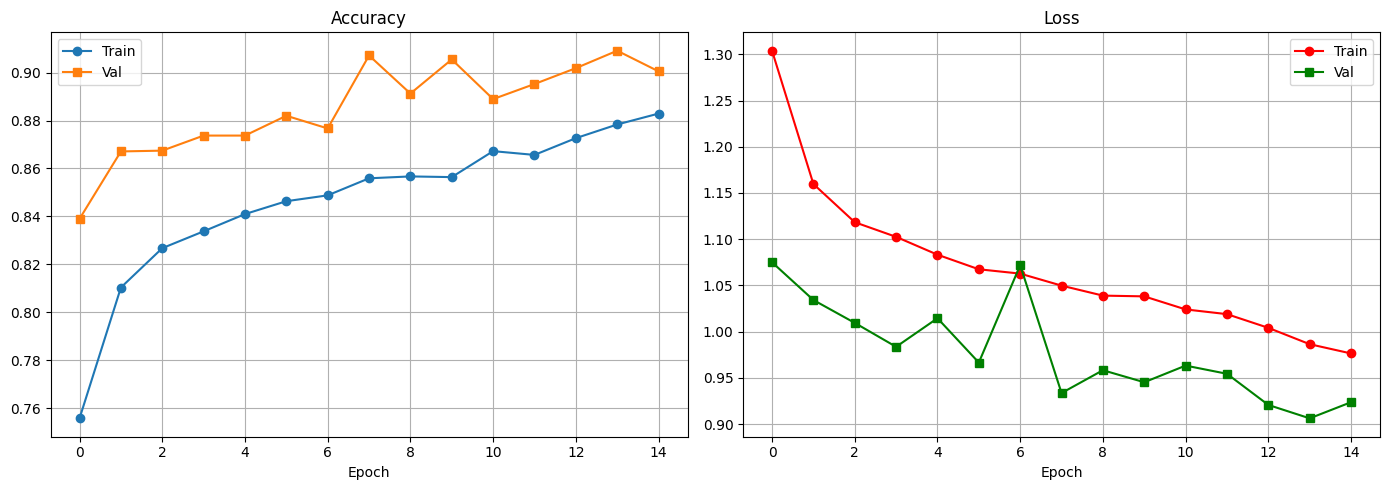

Saved to /content/drive/MyDrive/AgriVision_models/training_curves.png


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['train_acc'], label='Train', marker='o')
ax1.plot(history['val_acc'],   label='Val',   marker='s')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True)

ax2.plot(history['train_loss'], label='Train', marker='o', color='red')
ax2.plot(history['val_loss'],   label='Val',   marker='s', color='green')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plot_path = os.path.join(DRIVE_OUTPUT_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=120)
plt.show()
print(f'Saved to {plot_path}')